# Lab 8: Define and Solve an ML Problem of Your Choosing

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" # suppress info and warning messages
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import time
!pip install gensim


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In this lab assignment, you will follow the machine learning life cycle and implement a model to solve a machine learning problem of your choosing. You will select a data set and choose a predictive problem that the data set supports.  You will then inspect the data with your problem in mind and begin to formulate a  project plan. You will then implement the machine learning project plan. 

You will complete the following tasks:

1. Build Your DataFrame
2. Define Your ML Problem
3. Perform exploratory data analysis to understand your data.
4. Define Your Project Plan
5. Implement Your Project Plan:
    * Prepare your data for your model.
    * Fit your model to the training data and evaluate your model.
    * Improve your model's performance.

## Part 1: Build Your DataFrame

You will have the option to choose one of four data sets that you have worked with in this program:

* The "census" data set that contains Census information from 1994: `censusData.csv`
* Airbnb NYC "listings" data set: `airbnbListingsData.csv`
* World Happiness Report (WHR) data set: `WHR2018Chapter2OnlineData.csv`
* Book Review data set: `bookReviewsData.csv`

Note that these are variations of the data sets that you have worked with in this program. For example, some do not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for each of the four data sets available to you.

<b>Task:</b> In the code cell below, use the same method you have been using to load the data using `pd.read_csv()` and save it to DataFrame `df`. 

You can load each file as a new DataFrame to inspect the data before choosing your data set.

In [175]:
# File names of the four data sets
adultDataSet_filename = os.path.join(os.getcwd(), "data", "censusData.csv")
airbnbDataSet_filename = os.path.join(os.getcwd(), "data", "airbnbListingsData.csv")
WHRDataSet_filename = os.path.join(os.getcwd(), "data", "WHR2018Chapter2OnlineData.csv")
bookReviewDataSet_filename = os.path.join(os.getcwd(), "data", "bookReviewsData.csv")

df = pd.read_csv(bookReviewDataSet_filename)

df.head()


,Review,Positive Review
0,This was perhaps the best of Johannes Steinhof...,True
1,This very fascinating book is a story written ...,True
2,The four tales in this collection are beautifu...,True
3,The book contained more profanity than I expec...,False
4,We have now entered a second time of deep conc...,True


## Part 2: Define Your ML Problem

Next you will formulate your ML Problem. In the markdown cell below, answer the following questions:

1. List the data set you have chosen.
2. What will you be predicting? What is the label?
3. Is this a supervised or unsupervised learning problem? Is this a clustering, classification or regression problem? Is it a binary classificaiton or multi-class classifiction problem?
4. What are your features? (note: this list may change after your explore your data)
5. Explain why this is an important problem. In other words, how would a company create value with a model that predicts this label?

1. The dataset I chose is the book review dataset.

2. I will be doing a sentiment classification, predicting if it is a positive review or not.

3. This is a supervised classification problem.

4. The features is the review and the label is whether or not it is a positive review.

5. This is an important problem for companies because it can be applied to many realms in order to tell if a new product they released is good or not. Instead of reading through every individual review, they could have a model that is able to classify if a review is positive or not and be able to tell if majority of the consumers like it or not. 

## Part 3: Understand Your Data

The next step is to perform exploratory data analysis. Inspect and analyze your data set with your machine learning problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * addressing missingness, such as replacing missing values with means
    * finding and replacing outliers
    * renaming features and labels
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * performing specific data cleaning and preprocessing techniques for an NLP problem
    * addressing class imbalance in your data sample to promote fair AI
    

2. What machine learning model (or models) you would like to use that is suitable for your predictive problem and data?
    * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 
 
3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics and methods that are appropriate for your model?
    

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. If you are working on a classification problem, use techniques you have learned to determine if there is class imbalance.

<b>Task</b>: Use the techniques you have learned in this course to inspect and analyze your data. You can import additional packages that you have used in this course that you will need to perform this task.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-drown menu.

In [3]:
df.shape

(1973, 2)

In [4]:
nan_count = np.sum(df.isnull(), axis = 0)
nan_count

Review             0
Positive Review    0
dtype: int64

In [15]:
value_counts = df['Positive Review'].value_counts()
value_counts

False    993
True     980
Name: Positive Review, dtype: int64

In [176]:
df.dtypes

Review             object
Positive Review      bool
dtype: object

## Part 4: Define Your Project Plan

Now that you understand your data, in the markdown cell below, define your plan to implement the remaining phases of the machine learning life cycle (data preparation, modeling, evaluation) to solve your ML problem. Answer the following questions:

* Do you have a new feature list? If so, what are the features that you chose to keep and remove after inspecting the data? 
* Explain different data preparation techniques that you will use to prepare your data for modeling.
* What is your model (or models)?
* Describe your plan to train your model, analyze its performance and then improve the model. That is, describe your model building, validation and selection plan to produce a model that generalizes well to new data. 

I kept the same feature list as there was only one. 

For preparing the data, I want to try two ways to process the words into numerical representation: vectorize using Tf-idf and doing word embeddings. 

I plan to use two models: Logistic Regression and Decision Trees.

First I will develop the two base models and then perform a grid search cross validation to identify the best hyperparameter values for each model. Each model will have the Tf-idf and the word embedded version. After tuning the models and training and determining which processing of the text is best and which hyperparameters are the best for each model, I will test the models on unseen data to see which model generalizes the best. I also plan on using a movie review data set to see if it is able to generalize to that dataset and used as an overall sentiment classification tool. 

## Part 5: Implement Your Project Plan

<b>Task:</b> In the code cell below, import additional packages that you have used in this course that you will need to implement your project plan.

<b>Task:</b> Use the rest of this notebook to carry out your project plan. 

You will:

1. Prepare your data for your model.
2. Fit your model to the training data and evaluate your model.
3. Improve your model's performance by performing model selection and/or feature selection techniques to find best model for your problem.

Add code cells below and populate the notebook with commentary, code, analyses, results, and figures as you see fit. 

### Creating the Training and Testing Data

In [5]:
X = df['Review']
y = df['Positive Review']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25)

In [7]:
X_train.shape

(1479,)

### Transform the Text: Tf-IDF

In [45]:
vectorizer = TfidfVectorizer()

vectorizer.fit(X_train)

X_train_tfidf = vectorizer.transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [46]:
vocabulary_size = len(vectorizer.vocabulary_)

print(vocabulary_size)

18040


### Transform the Text: Word Embeddings

In [47]:
import gensim
X_word_embed = X.apply(lambda row: gensim.utils.simple_preprocess(row))

In [48]:
X_word_embed.head()

0    [this, was, perhaps, the, best, of, johannes, ...
1    [this, very, fascinating, book, is, story, wri...
2    [the, four, tales, in, this, collection, are, ...
3    [the, book, contained, more, profanity, than, ...
4    [we, have, now, entered, second, time, of, dee...
Name: Review, dtype: object

In [49]:
X_train_we, X_test_we, y_train_we, y_test_we = train_test_split(X_word_embed, y, test_size = 0.25)

X_train_we.shape

(1479,)

In [90]:
print("Begin")
word2vec_model = gensim.models.Word2Vec(X_train_we,
                                   vector_size=150,
                                   window=2,
                                   min_count=2)

print("End")

Begin
End


In [91]:
## Testing similarities
word2vec_model.wv.similarity(w1='good', w2='bad')

0.9613021

In [92]:
## Testing similarities
word2vec_model.wv.similarity(w1='book', w2='cat')

0.7912336

In [93]:
words = set(word2vec_model.wv.index_to_key)

print('Begin transforming X_train_we')
X_train_word_embeddings = np.array([np.array([word2vec_model.wv[word] for word in words if word in training_example])
                        for training_example in X_train_we], dtype=object)
print('Finish transforming X_train_we')

print('Begin transforming X_test_we')
X_test_word_embeddings = np.array([np.array([word2vec_model.wv[word] for word in words if word in training_example])
                        for training_example in X_test_we], dtype=object)
print('Finish transforming X_test_we')

Begin transforming X_train_we
Finish transforming X_train_we
Begin transforming X_test_we
Finish transforming X_test_we


In [94]:
X_train_feature_vector = []
for w in X_train_word_embeddings:
    if w.size:
        X_train_feature_vector.append(w.mean(axis=0))
    else:
        X_train_feature_vector.append(np.zeros(100, dtype=float))
        
X_test_feature_vector = []
for w in X_test_word_embeddings:
    if w.size:
        X_test_feature_vector.append(w.mean(axis=0))
    else:
        X_test_feature_vector.append(np.zeros(100, dtype=float))

### Build Logisitic Regression Model

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

Define different hyperparameters to test out.

In [55]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [100, 200, 300, 400, 500]
}

Find best hyperparameters for Logistic Regression for tfidf vectorization

In [95]:
LR_model = LogisticRegression()

print('TFIDF LR Grid Search...')

LR_grid_tfidf = GridSearchCV(LR_model, param_grid_lr, cv = 5)

LR_gridsearch_tfidf = LR_grid_tfidf.fit(X_train_tfidf, y_train)

print('Done TFIDF LR Grid Search')

print('Embedding LR Grid Search...')

LR_grid_we = GridSearchCV(LR_model, param_grid_lr, cv = 5)

LR_gridsearch_we = LR_grid_we.fit(X_train_feature_vector, y_train)

print('Done Embedding LR Grid Search')

TFIDF LR Grid Search...
Done TFIDF LR Grid Search
Embedding LR Grid Search...
Done Embedding LR Grid Search


In [96]:
best_c_tfidf = LR_gridsearch_tfidf.best_params_['C']
print('Best C for TFIDF LR: ', best_c_tfidf)

best_iter_tfidf = LR_gridsearch_tfidf.best_params_['max_iter']
print('Best iterations for TFIDF LR: ', best_iter_tfidf)

best_c_we = LR_gridsearch_we.best_params_['C']
print('Best C for embedding LR: ', best_c_we)

best_iter_we = LR_gridsearch_we.best_params_['max_iter']
print('Best iterations for emebedding LR: ', best_iter_we)

Best C for TFIDF LR:  100
Best iterations for TFIDF LR:  100
Best C for embedding LR:  0.1
Best iterations for emebedding LR:  100


Build and Test the Best Model

In [109]:
best_tfidf_lr = LogisticRegression(max_iter = best_iter_tfidf, C = best_c_tfidf)

best_tfidf_lr.fit(X_train_tfidf, y_train)

probability_predictions_tfidf = best_tfidf_lr.predict_proba(X_test_tfidf)

l_loss_tfidf = log_loss(y_test, probability_predictions_tfidf)

class_label_predictions_tfidf = best_tfidf_lr.predict(X_test_tfidf)

acc_score_tfidf = accuracy_score(y_test, class_label_predictions_tfidf)

tfidf_auc = roc_auc_score(y_test, class_label_predictions_tfidf)

y_train_pred = best_tfidf_lr.predict(X_train_tfidf)

train_accuracy_lr_fidf = accuracy_score(y_train, y_train_pred)

print("Training Accuracy of LR TFIDF: ", train_accuracy_lr_fidf)
print("Testing Accuracy of LR TFIDF:", acc_score_tfidf)
print("AUC of LR TFIDF:", tfidf_auc)

Training Accuracy of LR TFIDF:  1.0
Testing Accuracy of LR TFIDF: 0.8157894736842105
AUC of LR TFIDF: 0.8158602150537635


In [108]:
best_we_lr = LogisticRegression(max_iter = best_iter_we, C = best_c_we)

best_we_lr.fit(X_train_feature_vector, y_train)

probability_predictions_we = best_we_lr.predict_proba(X_test_feature_vector)

l_loss_we = log_loss(y_test, probability_predictions_we)

class_label_predictions_we = best_we_lr.predict(X_test_feature_vector)

acc_score_we = accuracy_score(y_test, class_label_predictions_we)

we_auc = roc_auc_score(y_test, class_label_predictions_we)

y_train_pred = best_we_lr.predict(X_train_feature_vector)

train_accuracy_we_fidf = accuracy_score(y_train, y_train_pred)

print("Training Accuracy of LR Embedding: ", train_accuracy_we_fidf)
print("Testing Accuracy of LR Embedding:", acc_score_we)
print("AUC of LR Embedding:", we_auc)

Training Accuracy of LR Embedding:  0.5348208248816768
Testing Accuracy of LR Embedding: 0.4939271255060729
AUC of LR Embedding: 0.49475478625754


From this we see that the logistic regression is not doing well with the word embedding, but is overfitting when it comes to the TFIDF. Future steps may be to try and tune the TFIDF vectorizer and word embedding parameters. Let's see if trying these different approaches using decision will improve the accuracy.

## Build Decision Trees

In [35]:
from sklearn.tree import DecisionTreeClassifier

In [60]:
param_grid = {
    'max_depth': [10, 20, 30, 50],
    'min_samples_leaf': [1,10, 25, 30, 50]
}

In [61]:
dt_classifier = DecisionTreeClassifier()

print('TFIDF DT Grid Search...')

dt_grid_tfidf = GridSearchCV(dt_classifier, param_grid, cv = 5)

dt_gridsearch_tfidf = dt_grid_tfidf.fit(X_train_tfidf, y_train)

print('Done TFIDF DT Grid Search')

print('Embedding DT Grid Search...')

dt_grid_we = GridSearchCV(dt_classifier, param_grid, cv = 5)

dt_gridsearch_we = dt_grid_we.fit(X_train_feature_vector, y_train)

print('Done Embedding DT Grid Search')

TFIDF DT Grid Search...
Done TFIDF DT Grid Search
Embedding DT Grid Search...
Done Embedding DT Grid Search


In [62]:
dt_tfidf_params = dt_gridsearch_tfidf.best_params_

print("best tfidf dt params: ", dt_tfidf_params)

dt_we_params = dt_gridsearch_we.best_params_

print("best word embedding dt params: ", dt_we_params)

best tfidf dt params:  {'max_depth': 30, 'min_samples_leaf': 10}
best word embedding dt params:  {'max_depth': 50, 'min_samples_leaf': 10}


Build and Test the Models w/ Best Parameters

In [110]:
dt_tfidf = DecisionTreeClassifier(max_depth = 30, min_samples_leaf = 10)
dt_tfidf.fit(X_train_tfidf, y_train)

probability_predictions_tfidf = dt_tfidf.predict_proba(X_test_tfidf)[:,1]
class_label_predictions_tfidf = dt_tfidf.predict(X_test_tfidf)

accuracy_tfidf = accuracy_score(y_test, class_label_predictions_tfidf)
auc_tfidf = roc_auc_score(y_test, probability_predictions_tfidf)

y_train_pred = dt_tfidf.predict(X_train_tfidf)
train_accuracy_dt_tfidf = accuracy_score(y_train, y_train_pred)

print("Training Accuracy of TFIDF DT: ", train_accuracy_dt_tfidf)
print('Testing Accuracy of TDIDF DT:', accuracy_tfidf)
print('AUC of TFIDF DT:', auc_tfidf)

Training Accuracy of TFIDF DT:  0.8417849898580122
Testing Accuracy of TDIDF DT: 0.5850202429149798
AUC of TFIDF DT: 0.6224675452399686


In [111]:
dt_we = DecisionTreeClassifier(max_depth = 50, min_samples_leaf = 10)
dt_we.fit(X_train_feature_vector, y_train)

probability_predictions_we = dt_we.predict_proba(X_test_feature_vector)[:,1]
class_label_predictions_we = dt_we.predict(X_test_feature_vector)

accuracy_we = accuracy_score(y_test, class_label_predictions_we)
auc_we = roc_auc_score(y_test, probability_predictions_we)

y_train_pred = dt_we.predict(X_train_feature_vector)
train_accuracy_dt_we = accuracy_score(y_train, y_train_pred)

print("Training Accuracy of Word Embedding DT: ", train_accuracy_dt_we)
print('Testing Accuracy of word embedding DT:', accuracy_we)
print('AUC of word embedding DT:', auc_we)

Training Accuracy of Word Embedding DT:  0.8032454361054767
Testing Accuracy of word embedding DT: 0.4979757085020243
AUC of word embedding DT: 0.4908126803042223


We find that the word Decision trees help to improve the training accuracy in the word embeddings, but it is still overfitting because the accuracy is basically 50% chance in the testing data.

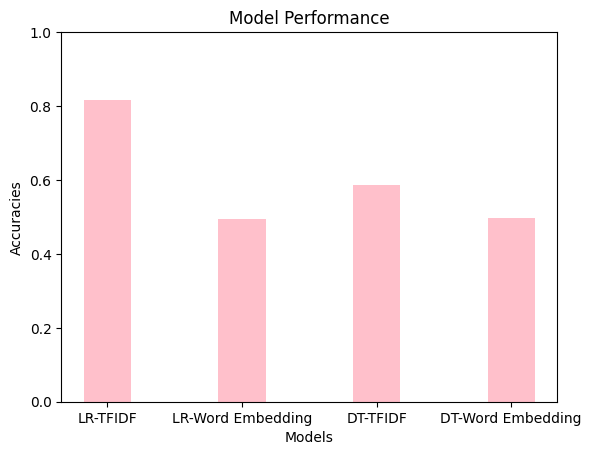

In [201]:
Accuracies = [acc_score_tfidf, acc_score_we, accuracy_tfidf, accuracy_we]

rg= np.arange(4)
width = 0.35

plt.bar(rg, Accuracies, width, label='Accuracies', color='pink')

labels = ['LR-TFIDF','LR-Word Embedding', 'DT-TFIDF', 'DT-Word Embedding']
plt.xticks(rg, labels)

plt.xlabel("Models")
plt.ylabel("Accuracies")


plt.ylim([0,1])
plt.title('Model Performance')
plt.show()


From this we see that Logistic Regression with TFIDF of the data leads to the highest testing accuracy. From this, we could try to optimize the vectorization to prevent overfitting. 

## Optimize the Model

<b> Our Baseline: <b>

Training Accuracy of LR TFIDF:  1.0

<b>Testing Accuracy of LR TFIDF: 0.8157894736842105

AUC of LR TFIDF: 0.8158602150537635

In [163]:
vectorizer = TfidfVectorizer(min_df=5, max_df=0.9, max_features=10000)

vectorizer.fit(X_train)

X_train_tfidf = vectorizer.transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [164]:
vocabulary_size = len(vectorizer.vocabulary_)

print(vocabulary_size)

3654


In [165]:
LR_model = LogisticRegression()

print('TFIDF LR Grid Search...')

LR_grid_tfidf = GridSearchCV(LR_model, param_grid_lr, cv = 5)

LR_gridsearch_tfidf = LR_grid_tfidf.fit(X_train_tfidf, y_train)

print('Done TFIDF LR Grid Search')

TFIDF LR Grid Search...
Done TFIDF LR Grid Search


In [166]:
best_c = LR_gridsearch_tfidf.best_params_['C']
print('Best C: ', best_c)

best_iter = LR_gridsearch_tfidf.best_params_['max_iter']
print('Best iterations: ', best_iter)

Best C:  10
Best iterations:  100


In [167]:
opt_tfidf_lr = LogisticRegression(max_iter = best_iter, C = best_c)

opt_tfidf_lr.fit(X_train_tfidf, y_train)

probability_predictions = opt_tfidf_lr.predict_proba(X_test_tfidf)

l_loss = log_loss(y_test, probability_predictions)

class_label_predictions = opt_tfidf_lr.predict(X_test_tfidf)

acc_score = accuracy_score(y_test, class_label_predictions)

auc = roc_auc_score(y_test, class_label_predictions)

y_train_pred = opt_tfidf_lr.predict(X_train_tfidf)

train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy: ", train_accuracy)
print("Testing Accuracy:", acc_score)
print("AUC: ", auc)

Training Accuracy:  0.9979716024340771
Testing Accuracy: 0.8299595141700404
AUC:  0.8300386834513507


After testing around different values for the vectorizer and finding optimal parameters for the logisitic regression, I was able to get the testing accuracy to become 0.8299, which is not much different from the prior testing accuracy of 0.8157894736842105. 

## Test if this can be applied to movie review sentiment

Outside Data retrieved from Kaggle: https://www.kaggle.com/datasets/yasserh/imdb-movie-ratings-sentiment-analysis

In [185]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "movie.csv"

# Load the latest version
df_movies = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/imdb-movie-ratings-sentiment-analysis", file_path )

df_movies.head()

/tmp/ipykernel_1596/2735626227.py:7: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df_movies = kagglehub.load_dataset(


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [186]:
df_movies['label'] = df_movies['label'].astype(bool)

In [187]:
df_movies

,text,label
0,I grew up (b. 1965) watching and loving the Th...,False
1,"When I put this movie in my DVD player, and sa...",False
2,Why do people who do not know what a particula...,False
3,Even though I have great interest in Biblical ...,False
4,Im a die hard Dads Army fan and nothing will e...,True
...,...,...
39995,"""Western Union"" is something of a forgotten cl...",True
39996,This movie is an incredible piece of work. It ...,True
39997,My wife and I watched this movie because we pl...,False
39998,"When I first watched Flatliners, I was amazed....",True


In [188]:
X_movies = df_movies['text']
y_movies = df_movies['label']

In [189]:
movies_text = vectorizer.transform(X_movies)

In [190]:
movies_prediction = opt_tfidf_lr.predict(movies_text)
movie_acc = accuracy_score(y_movies, movies_prediction)

print("Testing Accuracy:", movie_acc)

Testing Accuracy: 0.7735


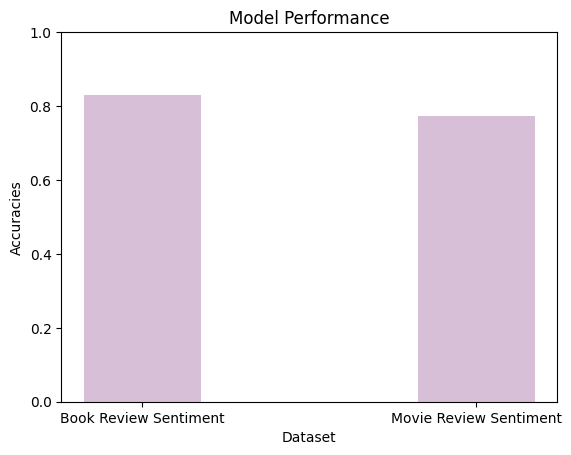

In [200]:
Accuracies = [acc_score, movie_acc]

rg= np.arange(2)

plt.bar(rg, Accuracies, width, label='Accuracies', color='thistle')

labels = ['Book Review Sentiment','Movie Review Sentiment']
plt.xticks(rg, labels)

plt.xlabel("Dataset")
plt.ylabel("Accuracies")


plt.ylim([0,1])
plt.title('Model Performance')
plt.show()


From this, we see that the logistic regression model trained on book on book reviews for sentiment classification can somewhat be applied to reviews in a different realm. While the accuracy kind of decreased and we were not able to increase the accuracy to be over 0.85, it still does somewhat well. In the future, we could work on finding the optimal parameters to see if we can increase the testing accuracy or get